Loading Tools and Dataset

In [ ]:
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf
from sklearn.model_selection import train_test_split
from ast import literal_eval
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [56]:
arxiv_data=pd.read_csv("/content/drive/MyDrive/arxiv_data_210930-054931.csv")

In [57]:
arxiv_data.head()

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural...,Graph neural networks (GNNs) have been widely ...
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual...,Deep networks and decision forests (such as ra...
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network v...,Graph convolutional networks (GCNs) are powerf...
3,"['cs.LG', 'cs.CR']",Releasing Graph Neural Networks with Different...,With the increasing popularity of Graph Neural...
4,['cs.LG'],Recurrence-Aware Long-Term Cognitive Network f...,Machine learning solutions for pattern classif...


Data Cleaning

In [ ]:
arxiv_data.shape

(56181, 3)

In [58]:
arxiv_data.isnull().sum()

,0
terms,0
titles,0
abstracts,0


In [59]:
arxiv_data.duplicated().sum()

np.int64(15054)

In [60]:
# getting unique labels
labels_column = arxiv_data['terms'].apply(literal_eval)
labels = labels_column.explode().unique()
print("labels :",labels)
print("lenght :",len(labels))

labels : ['cs.LG' 'cs.AI' 'cs.CR' ... 'D.1.3; G.4; I.2.8; I.2.11; I.5.3; J.3'
 '68T07, 68T45, 68T10, 68T50, 68U35' 'I.2.0; G.3']
lenght : 1177


In [63]:
# remove duplicate entries based on the "titles" (terms) column
# This filters the DataFrame, keeping only the rows where the titles are not duplicated.
arxiv_data = arxiv_data[~arxiv_data['titles'].duplicated()]
print(f"There are {len(arxiv_data)} rows in the deduplicated dataset.")
# There are some terms with occurrence as low as 1.
print(sum(arxiv_data['terms'].value_counts()==1))
# how many unique terms
print(arxiv_data['terms'].nunique())

There are 41105 rows in the deduplicated dataset.
2503
3401


In [64]:
# Filtering the rare terms. (it keeps only those rows where the "terms" value occurs more than once in the original DataFrame.)
arxiv_data_filtered = arxiv_data.groupby('terms').filter(lambda x: len(x) > 1)
arxiv_data_filtered.shape

(38602, 3)

In [65]:
# It evaluates the given string containing a Python literal or container display (e.g., a list or dictionary) and returns the corresponding Python object.
arxiv_data_filtered['terms'] = arxiv_data_filtered['terms'].apply(lambda x: literal_eval(x))
arxiv_data_filtered['terms'].values[:3]

array([list(['cs.LG']), list(['cs.LG', 'cs.AI']),
       list(['cs.LG', 'cs.CR', 'stat.ML'])], dtype=object)

train and test split.

In [73]:
test_split = 0.1

# Initial train and test split.
# The stratify parameter ensures that the splitting is done in a way that preserves the same distribution of labels (terms) in both the training and test sets.
train_df, test_df = train_test_split(arxiv_data_filtered,test_size=test_split,stratify=arxiv_data_filtered["terms"].values,)

# Splitting the test set further into validation
# and new test sets.
val_df = test_df.sample(frac=0.5)
test_df.drop(val_df.index, inplace=True)


print(f"Number of rows in training set: {len(train_df)}")
print(f"Number of rows in validation set: {len(val_df)}")
print(f"Number of rows in test set: {len(test_df)}")

Number of rows in training set: 34741
Number of rows in validation set: 1930
Number of rows in test set: 1931


In [74]:
# creates a TensorFlow RaggedTensor (terms) from the values in the "terms" column of the train_df DataFrame. A RaggedTensor is a tensor with non-uniform shapes
terms = tf.ragged.constant(train_df['terms'].values)
# This line creates a StringLookup layer in TensorFlow. The purpose of this layer is to map strings to integer indices and vice versa. The output_mode="multi_hot" indicates that the layer will output a multi-hot encoded representation of the input strings.
lookup = tf.keras.layers.StringLookup(output_mode='multi_hot')
# This step adapts the StringLookup layer to the unique values in the "terms" column, building the vocabulary.
lookup.adapt(terms)
# retrieve vocabulary
vocab = lookup.get_vocabulary()

print("Vocabulary:\n")
print(vocab)

Vocabulary:

['[UNK]', np.str_('cs.CV'), np.str_('cs.LG'), np.str_('stat.ML'), np.str_('cs.AI'), np.str_('eess.IV'), np.str_('cs.RO'), np.str_('cs.CL'), np.str_('cs.NE'), np.str_('cs.GR'), np.str_('cs.CR'), np.str_('math.OC'), np.str_('eess.SP'), np.str_('cs.SI'), np.str_('cs.MM'), np.str_('cs.SY'), np.str_('cs.IR'), np.str_('eess.SY'), np.str_('cs.MA'), np.str_('cs.HC'), np.str_('math.IT'), np.str_('cs.IT'), np.str_('cs.DC'), np.str_('stat.AP'), np.str_('cs.CY'), np.str_('stat.ME'), np.str_('stat.TH'), np.str_('math.ST'), np.str_('eess.AS'), np.str_('cs.DS'), np.str_('cs.SD'), np.str_('q-bio.QM'), np.str_('q-bio.NC'), np.str_('stat.CO'), np.str_('cs.CG'), np.str_('cs.GT'), np.str_('cs.NI'), np.str_('math.NA'), np.str_('cs.SE'), np.str_('I.2.6'), np.str_('cs.NA'), np.str_('physics.chem-ph'), np.str_('cs.DB'), np.str_('physics.comp-ph'), np.str_('cond-mat.dis-nn'), np.str_('q-bio.BM'), np.str_('math.PR'), np.str_('cs.PL'), np.str_('cs.LO'), np.str_('68T45'), np.str_('cs.AR'), np.str_('p

In [77]:
sample_label = train_df["terms"].iloc[0]
print(f"Original label: {sample_label}")

label_binarized = lookup([sample_label])
print(f"Label-binarized representation: {label_binarized}")

Original label: ['stat.ML', 'cs.LG']
Label-binarized representation: [[0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


In [78]:
# following lines::
# which is used for automatic adjustment of resource usage by TensorFlow's data loading pipeline.

#max_seqlen: Maximum sequence length. It indicates the maximum length allowed for sequences.
max_seqlen = 150
#batch_size: Batch size. It specifies the number of samples to use in each iteration.
batch_size = 128
#padding_token: A token used for padding sequences.
padding_token = "<pad>"
#auto = tf.data.AUTOTUNE: auto is assigned the value tf.data.AUTOTUNE,
auto = tf.data.AUTOTUNE

def make_dataset(dataframe, is_train=True):
    # creating sequences of labesls
    labels = tf.ragged.constant(dataframe["terms"].values)
    #This line uses the previously defined lookup layer to convert the ragged tensor of labels into a binarized representation. The resulting label_binarized is a NumPy array.
    label_binarized = lookup(labels).numpy()
    # creating sequences of text.
    dataset = tf.data.Dataset.from_tensor_slices((dataframe["abstracts"].values, label_binarized))
    # shuffling data basis on condition
    dataset = dataset.shuffle(batch_size * 10) if is_train else dataset
    return dataset.batch(batch_size)

"""
In summary, the make_dataset function is designed to create a
dataset suitable for training a model. It takes a dataframe as input,
assumes it has "abstracts" and "terms" columns, and creates a dataset of
batches where each batch consists of abstract
sequences and their corresponding binarized label sequences.
"""

'\nIn summary, the make_dataset function is designed to create a\ndataset suitable for training a model. It takes a dataframe as input,\nassumes it has "abstracts" and "terms" columns, and creates a dataset of\nbatches where each batch consists of abstract\nsequences and their corresponding binarized label sequences.\n'

In [83]:
train_dataset = make_dataset(train_df, is_train=True)
validation_dataset = make_dataset(val_df, is_train=False)
test_dataset = make_dataset(test_df, is_train=False)

In [88]:
text_batch, label_batch = next(iter(train_dataset))
for i, text in enumerate(text_batch[:5]):
    label = label_batch[i].numpy()[None, ...]
    print(f"Abstract: {text}")
    print(f"Label(s): {invert_multi_hot(label[0], vocab)}")
    print(" ")

Abstract: b'Convolutional neural networks (CNNs) have proven effective for image\nprocessing tasks, such as object recognition and classification. Recently, CNNs\nhave been enhanced with concepts of attention, similar to those found in\nbiology. Much of this work on attention has focused on effective serial spatial\nprocessing. In this paper, I introduce a simple procedure for applying\nfeature-based attention (FBA) to CNNs and compare multiple implementation\noptions. FBA is a top-down signal applied globally to an input image which\naides in detecting chosen objects in cluttered or noisy settings. The concept\nof FBA and the implementation details tested here were derived from what is\nknown (and debated) about biological object- and feature-based attention. The\nimplementations of FBA described here increase performance on challenging\nobject detection tasks using a procedure that is simple, fast, and does not\nrequire additional iterative training. Furthermore, the comparisons perf

In [90]:
def invert_multi_hot_demo(encoded_labels):
    """Reverse a single multi-hot encoded label using the 'vocab' variable."""
    hot_indices = np.argwhere(encoded_labels == 1.0)[..., 0]
    return np.take(vocab, hot_indices)

# Note: train_dataset now contains (vectorized_text, label)
text_batch, label_batch = next(iter(train_dataset))

print(f"Vectorized text shape: {text_batch.shape}")
print("--- Sample Labels ---\n")

for i in range(5):
    label = label_batch[i].numpy()
    decoded_labels = invert_multi_hot_demo(label)
    print(f"Sample {i+1} Labels: {decoded_labels}")

Vectorized text shape: (128,)
--- Sample Labels ---

Sample 1 Labels: ['cs.CV']
Sample 2 Labels: ['cs.CV']
Sample 3 Labels: ['cs.CV']
Sample 4 Labels: ['cs.LG']
Sample 5 Labels: ['cs.CV' 'cs.LG']


In [91]:
# This code calculates the size of the vocabulary in the "abstracts" column of the train_df DataFrame.

# Creating vocabulary with uniques words
vocabulary = set()
train_df["abstracts"].str.lower().str.split().apply(vocabulary.update)
vocabulary_size = len(vocabulary)
print(vocabulary_size)

159123


Text Vectorization

In [92]:
# Initializes a TextVectorization layer
text_vectorizer = layers.TextVectorization(max_tokens=vocabulary_size,ngrams=2,output_mode="tf_idf")
# `TextVectorization` layer needs to be adapted as per the vocabulary from our
# training set.
text_vectorizer.adapt(train_dataset.map(lambda text, label: text))

In [93]:

train_dataset = train_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
validation_dataset = validation_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)
test_dataset = test_dataset.map(lambda text, label: (text_vectorizer(text), label), num_parallel_calls=auto).prefetch(auto)


Model training

In [94]:
# creating shallow_mlp_model (MLP)
from tensorflow.keras.callbacks import EarlyStopping

# Creating shallow_mlp_model (MLP) with the vectorizer integrated
model1 = keras.Sequential([
    # Adding the vectorizer as the first layer ensures raw strings are handled
    layers.Input(shape=(1,), dtype=tf.string),
    text_vectorizer,

    # First hidden layer
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),

    # Second hidden layer
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),

    # Output layer
    layers.Dense(lookup.vocabulary_size(), activation='sigmoid')
])

# Compile the model
model1.compile(loss="binary_crossentropy", optimizer='adam', metrics=['binary_accuracy'])

# Add early stopping
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

# Re-create raw datasets because we integrated the vectorizer into the model
train_dataset_raw = make_dataset(train_df, is_train=True)
validation_dataset_raw = make_dataset(val_df, is_train=False)

# Train the model using raw strings
history = model1.fit(
    train_dataset_raw,
    validation_data=validation_dataset_raw,
    epochs=20,
    callbacks=[early_stopping]
)

Epoch 1/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 600s 2s/step - binary_accuracy: 0.9840 - loss: 0.0469 - val_binary_accuracy: 0.9943 - val_loss: 0.0185
Epoch 2/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 620s 2s/step - binary_accuracy: 0.9950 - loss: 0.0174 - val_binary_accuracy: 0.9944 - val_loss: 0.0181
Epoch 3/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - binary_accuracy: 0.9959 - loss: 0.0135 - val_binary_accuracy: 0.9944 - val_loss: 0.0181
Epoch 4/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 606s 2s/step - binary_accuracy: 0.9966 - loss: 0.0113 - val_binary_accuracy: 0.9944 - val_loss: 0.0186
Epoch 5/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 599s 2s/step - binary_accuracy: 0.9971 - loss: 0.0096 - val_binary_accuracy: 0.9943 - val_loss: 0.0195
Epoch 6/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 613s 2s/step - binary_accuracy: 0.9975 - loss: 0.0085 - val_binary_accuracy: 0.9944 - val_loss: 0.0205
Epoch 7/20
272/272 ━━━━━━━━━━━━━━━━━━━━ 625s 2s/step - binary_accuracy: 0.9978 - loss: 0.0077 - val_binary_accuracy: 0.9944 - val_loss: 0.0204

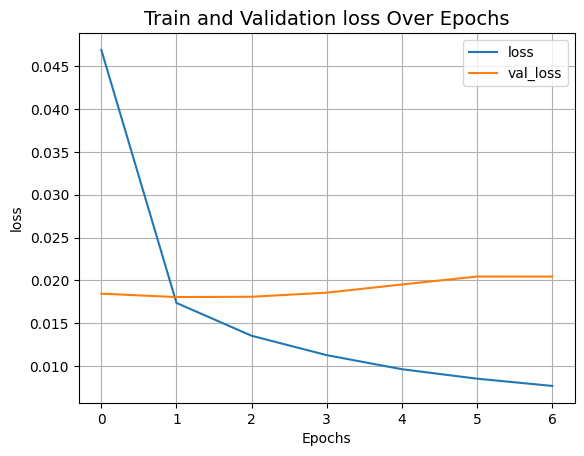

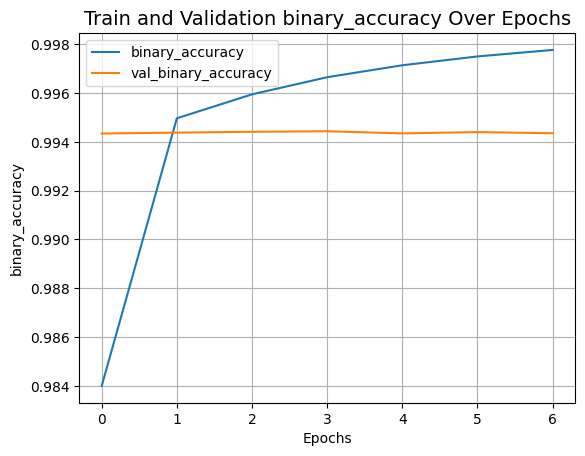

In [123]:
# plotting loss
def plot_result(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()


plot_result("loss")
plot_result("binary_accuracy")

Model Evaluation

In [125]:
test_dataset_raw = make_dataset(test_df, is_train=False)

# model evaluation on test and val dataset
_, binary_acc1 = model1.evaluate(test_dataset_raw)
_, binary_acc2 = model1.evaluate(validation_dataset_raw)

print(f"Categorical accuracy on the test set: {round(binary_acc1 * 100, 2)}%.")
print(f"Categorical accuracy on the validation set: {round(binary_acc2 * 100, 2)}%.")

16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 477ms/step - binary_accuracy: 0.9946 - loss: 0.0181
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 597ms/step - binary_accuracy: 0.9944 - loss: 0.0181
Categorical accuracy on the test set: 99.46%.
Categorical accuracy on the validation set: 99.44%.


Save Model and Text Vectorizer:

In [136]:
import os
import pickle

# Save the model
os.makedirs("model", exist_ok=True)
model1.save("model/model.h5")

# Save the configuration of the text vectorizer
saved_text_vectorizer_config = text_vectorizer.get_config()
with open("model/text_vectorizer_config.pkl", "wb") as f:
    pickle.dump(saved_text_vectorizer_config, f)

# Save the weights of the text vectorizer
with open("model/text_vectorizer_weights.pkl", "wb") as f:
    pickle.dump(text_vectorizer.get_weights(), f)

# Save the vocabulary
with open("model/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

Load Model and Text Vectorizer:

In [137]:
from tensorflow import keras
import pickle
from tensorflow.keras.layers import TextVectorization

# Load the model
loaded_model = keras.models.load_model("model/model.h5")

# Load the configuration of the text vectorizer
with open("model/text_vectorizer_config.pkl", "rb") as f:
    saved_text_vectorizer_config = pickle.load(f)

# Create a new TextVectorization layer with the saved configuration
loaded_text_vectorizer = TextVectorization.from_config(saved_text_vectorizer_config)

# Load the saved weights into the new TextVectorization layer
with open("model/text_vectorizer_weights.pkl", "rb") as f:
    weights = pickle.load(f)
    loaded_text_vectorizer.set_weights(weights)

In [135]:
# Load the vocabulary
with open("model/vocab.pkl", "rb") as f:
    loaded_vocab = pickle.load(f)

Model Prediction

In [85]:
def invert_multi_hot(encoded_labels, vocab):
    """Reverse a single multi-hot encoded label to a tuple of vocab terms."""
    hot_indices = np.argwhere(encoded_labels == 1)[..., 0]
    return np.take(vocab, hot_indices)

In [117]:
import tensorflow as tf

def predict_category(abstract, model, label_lookup):
    # Make predictions using the loaded model. The model handles vectorization internally.
    # The model expects raw string input, as the TextVectorization layer is its first layer.
    # Explicitly convert the abstract to a tf.constant tensor.
    predictions = model.predict(tf.constant([abstract]))

    # Convert predictions to human-readable labels
    predicted_labels = label_lookup(np.round(predictions).astype(int)[0])

    return predicted_labels

In [118]:
# Example usage
new_abstract = "Graph neural networks (GNNs) have been widely used to learn vector\nrepresentation of graph-structured data and achieved better task performance\nthan conventional methods. The foundation of GNNs is the message passing\nprocedure, which propagates the information in a node to its neighbors. Since\nthis procedure proceeds one step per layer, the range of the information\npropagation among nodes is small in the lower layers, and it expands toward the\nhigher layers. Therefore, a GNN model has to be deep enough to capture global\nstructural information in a graph. On the other hand, it is known that deep GNN\nmodels suffer from performance degradation because they lose nodes' local\ninformation, which would be essential for good model performance, through many\nmessage passing steps. In this study, we propose multi-level attention pooling\n(MLAP) for graph-level classification tasks, which can adapt to both local and\nglobal structural information in a graph. It has an attention pooling layer for\neach message passing step and computes the final graph representation by\nunifying the layer-wise graph representations. The MLAP architecture allows\nmodels to utilize the structural information of graphs with multiple levels of\nlocalities because it preserves layer-wise information before losing them due\nto oversmoothing. Results of our experiments show that the MLAP architecture\nimproves the graph classification performance compared to the baseline\narchitectures. In addition, analyses on the layer-wise graph representations\nsuggest that aggregating information from multiple levels of localities indeed\nhas the potential to improve the discriminability of learned graph\nrepresentations."

# Create a wrapper function for invert_multi_hot that includes the loaded_vocab
# This ensures the correct number of arguments are passed to invert_multi_hot
my_label_lookup_func = lambda encoded_labels: invert_multi_hot(encoded_labels, loaded_vocab)

print("Predicting...")
predicted_categories = predict_category(
    new_abstract,
    loaded_model,
    my_label_lookup_func
)

print("Predicted Categories:", predicted_categories)

Predicting...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
Predicted Categories: ['cs.LG']


In [121]:
predicted_categories = predict_category(new_abstract, loaded_model, my_label_lookup_func)
print("Predicted Categories:", predicted_categories)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Predicted Categories: ['cs.LG' 'stat.ML']


Recommendation System

In [ ]:
arxiv_data.drop(columns=['terms','abstracts'], inplace=True)
arxiv_data

,titles
0,Multi-Level Attention Pooling for Graph Neural...
1,Decision Forests vs. Deep Networks: Conceptual...
2,Power up! Robust Graph Convolutional Network v...
3,Releasing Graph Neural Networks with Different...
4,Recurrence-Aware Long-Term Cognitive Network f...
...,...
56176,Mining Spatio-temporal Data on Industrializati...
56177,Wav2Letter: an End-to-End ConvNet-based Speech...
56178,Deep Reinforcement Learning with Double Q-lear...
56179,Generalized Low Rank Models


In [126]:
arxiv_data.drop_duplicates(inplace= True)
arxiv_data.reset_index(drop= True,inplace = True)

In [127]:
pd.set_option('display.max_colwidth', None)
arxiv_data

,terms,titles,abstracts
0,['cs.LG'],Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities,"Graph neural networks (GNNs) have been widely used to learn vector\nrepresentation of graph-structured data and achieved better task performance\nthan conventional methods. The foundation of GNNs is the message passing\nprocedure, which propagates the information in a node to its neighbors. Since\nthis procedure proceeds one step per layer, the range of the information\npropagation among nodes is small in the lower layers, and it expands toward the\nhigher layers. Therefore, a GNN model has to be deep enough to capture global\nstructural information in a graph. On the other hand, it is known that deep GNN\nmodels suffer from performance degradation because they lose nodes' local\ninformation, which would be essential for good model performance, through many\nmessage passing steps. In this study, we propose multi-level attention pooling\n(MLAP) for graph-level classification tasks, which can adapt to both local and\nglobal structural information in a graph. It has an attention pooling layer for\neach message passing step and computes the final graph representation by\nunifying the layer-wise graph representations. The MLAP architecture allows\nmodels to utilize the structural information of graphs with multiple levels of\nlocalities because it preserves layer-wise information before losing them due\nto oversmoothing. Results of our experiments show that the MLAP architecture\nimproves the graph classification performance compared to the baseline\narchitectures. In addition, analyses on the layer-wise graph representations\nsuggest that aggregating information from multiple levels of localities indeed\nhas the potential to improve the discriminability of learned graph\nrepresentations."
1,"['cs.LG', 'cs.AI']",Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes,"Deep networks and decision forests (such as random forests and gradient\nboosted trees) are the leading machine learning methods for structured and\ntabular data, respectively. Many papers have empirically compared large numbers\nof classifiers on one or two different domains (e.g., on 100 different tabular\ndata settings). However, a careful conceptual and empirical comparison of these\ntwo strategies using the most contemporary best practices has yet to be\nperformed. Conceptually, we illustrate that both can be profitably viewed as\n""partition and vote"" schemes. Specifically, the representation space that they\nboth learn is a partitioning of feature space into a union of convex polytopes.\nFor inference, each decides on the basis of votes from the activated nodes.\nThis formulation allows for a unified basic understanding of the relationship\nbetween these methods. Empirically, we compare these two strategies on hundreds\nof tabular data settings, as well as several vision and auditory settings. Our\nfocus is on datasets with at most 10,000 samples, which represent a large\nfraction of scientific and biomedical datasets. In general, we found forests to\nexcel at tabular and structured data (vision and audition) with small sample\nsizes, whereas deep nets performed better on structured data with larger sample\nsizes. This suggests that further gains in both scenarios may be realized via\nfurther combining aspects of forests and networks. We will continue revising\nthis technical report in the coming months with updated results."
2,"['cs.LG', 'cs.CR', 'stat.ML']",Power up! Robust Graph Convolutional Network via Graph Powering,"Graph convolutional networks (GCNs) are powerful tools for graph-structured\ndata. However, they have been recently shown to be vulnerable to topological\nattacks. To enhance adversarial robustness, we go beyond spectral graph theory\nto robust graph theory. By challenging the classical graph Laplacian, we\npropose a new convolution operator t

Sentence Transformer

In [ ]:
!pip install -U -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer, util

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [ ]:
sentences = arxiv_data['titles']

In [ ]:
embeddings = model.encode(sentences.tolist())

In [35]:
embeddings.shape

(56181, 384)

Printing the Embeddings

In [36]:
c=0

for sentence,embedding in zip(sentences,embeddings):
  print("sentence:",sentence)
  print("embedding:",len(embedding))
  print("")
  if(c>=5):
    break
  c+=1

sentence: Multi-Level Attention Pooling for Graph Neural Networks: Unifying Graph Representations with Multiple Localities
embedding: 384

sentence: Decision Forests vs. Deep Networks: Conceptual Similarities and Empirical Differences at Small Sample Sizes
embedding: 384

sentence: Power up! Robust Graph Convolutional Network via Graph Powering
embedding: 384

sentence: Releasing Graph Neural Networks with Differential Privacy Guarantees
embedding: 384

sentence: Recurrence-Aware Long-Term Cognitive Network for Explainable Pattern Classification
embedding: 384

sentence: Lifelong Graph Learning
embedding: 384



Save Files

In [129]:
import pickle

with open("model/embeddings.pkl",'wb') as f:
  pickle.dump(embeddings,f)

with open("model/sentences.pkl",'wb') as f:
  pickle.dump(sentences,f)

with open("model/rec_model.pkl",'wb') as f:
  pickle.dump(model,f)

Recommendation of Similar Papers

In [38]:
import pickle

embeddings=pickle.load(open("model/embeddings.pkl",'rb'))
sentences=pickle.load(open("model/sentences.pkl",'rb'))
rec_model=pickle.load(open("model/rec_model.pkl",'rb'))

In [52]:
import torch

def recommendation(input_paper):
    # Calculate cosine similarity scores between the embeddings of input_paper and all papers in the dataset.
    cosine_scores = util.cos_sim(embeddings, rec_model.encode(input_paper))

    # Get the indices of the top-k most similar papers based on cosine similarity.
    top_similar_papers = torch.topk(cosine_scores, dim=0, k=5, sorted=True)

    # Retrieve the titles of the top similar papers.
    papers_list = []
    for i in top_similar_papers.indices:
        papers_list.append(sentences[i.item()])

    return papers_list

In [128]:
# exampel usage 1: (use this paper as input (Attention is All you Need))
input_paper = input("Enter the title of any paper you like  ")
recommend_papers = recommendation(input_paper)


print("We recommend to read this paper............")
print("=============================================")
recommend_papers


Enter the title of any paper you like  Attention is All you Need
We recommend to read this paper............


['Attention that does not Explain Away',
 'Attention that does not Explain Away',
 'Attention that does not Explain Away',
 'Area Attention',
 'Area Attention']